<a href="https://colab.research.google.com/github/FareyaHossain/unsupervised-music-generation/blob/main/22301679_Fareya_Hossain_523.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
!pip install pretty_midi
import numpy as np
import os
import random
import shutil
import zipfile
import pretty_midi
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

UPLOAD DATASET

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving maestro-v3.0.0-midi.zip to maestro-v3.0.0-midi.zip


In [ ]:
with zipfile.ZipFile("maestro-v3.0.0-midi.zip", 'r') as zip_ref:
    zip_ref.extractall("data/raw_midi")

print("Unzipped done")

Unzipped done


CHECK FILES

In [ ]:
print(os.listdir("data"))
print(os.listdir("data/raw_midi")[:10])

['small_dataset', 'raw_midi']
['maestro-v3.0.0']


COLLECT MIDI FILE PATHS

In [ ]:
midi_files = []

for root, dirs, files in os.walk("data/raw_midi"):
    for file in files:
        if file.endswith(".mid") or file.endswith(".midi"):
            midi_files.append(os.path.join(root, file))

print("Total MIDI files:", len(midi_files))
print("Sample:", midi_files[:5])



Total MIDI files: 1276
Sample: ['data/raw_midi/maestro-v3.0.0/2015/MIDI-Unprocessed_R2_D1-2-3-6-7-8-11_mid--AUDIO-from_mp3_07_R2_2015_wav--2.midi', 'data/raw_midi/maestro-v3.0.0/2015/MIDI-Unprocessed_R1_D1-9-12_mid--AUDIO-from_mp3_09_R1_2015_wav--4.midi', 'data/raw_midi/maestro-v3.0.0/2015/MIDI-Unprocessed_R1_D2-13-20_mid--AUDIO-from_mp3_18_R1_2015_wav--1.midi', 'data/raw_midi/maestro-v3.0.0/2015/MIDI-Unprocessed_R1_D2-13-20_mid--AUDIO-from_mp3_20_R1_2015_wav--4.midi', 'data/raw_midi/maestro-v3.0.0/2015/MIDI-Unprocessed_R1_D1-9-12_mid--AUDIO-from_mp3_09_R1_2015_wav--3.midi']


CREATE SMALL DATASET

In [ ]:
target_dir = "data/small_dataset"
os.makedirs(target_dir, exist_ok=True)

sample = random.sample(midi_files, 80)

for path in sample:
    shutil.copy(path, target_dir)

print("Small Dataset :", len(sample))

Small Dataset : 80


MIDI → PIANO ROLL FUNCTION

In [ ]:
def midi_to_piano_roll(path, fs=16):
    midi = pretty_midi.PrettyMIDI(path)
    roll = midi.get_piano_roll(fs=fs).T
    roll[roll > 0] = 1
    return roll

PREPROCESSING

In [ ]:
data = []
window = 100

for file in os.listdir("data/small_dataset"):
    path = os.path.join("data/small_dataset", file)

    try:
        roll = midi_to_piano_roll(path)
        for i in range(0, len(roll) - window, window):
            chunk = roll[i:i+window]

            if chunk.shape == (100,128):
                data.append(chunk)



    except:
        continue

data = np.array([x for x in data if np.sum(x) > 10])

print("Final Dataset shape:", data.shape)

Final Dataset shape: (7680, 100, 128)


In [ ]:
import numpy as np
data = np.array([x for x in data if x.shape == (100,128)])

print("Clean dataset:", data.shape)

Clean dataset: (7680, 100, 128)


In [ ]:
print("Non-zero values:", np.sum(data[0]))

Non-zero values: 337.0


VISUALIZE DATA

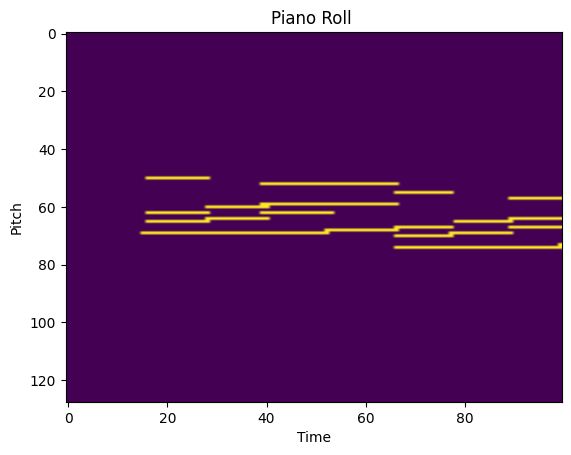

In [ ]:
plt.imshow(data[0].T, aspect='auto')
plt.title("Piano Roll ")
plt.xlabel("Time")
plt.ylabel("Pitch")
plt.show()

LISTEN SAMPLE

In [ ]:
def create_midi(pred, filename):
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    for t, frame in enumerate(pred):
        for note in range(128):
            if frame[note] > 0.1:
                note_obj = pretty_midi.Note(
                    velocity=100,
                    pitch=note,
                    start=t * 0.1,
                    end=(t + 1) * 0.1
                )
                instrument.notes.append(note_obj)

    midi.instruments.append(instrument)
    midi.write(filename)

create_midi(data[0], "original.mid")

from google.colab import files
files.download("original.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TRAIN VAL  SPLIT

In [ ]:
X_train, X_val = train_test_split(data, test_size=0.2, random_state=42)

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")

print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (6144, 100, 128)
Val: (1536, 100, 128)


TASK 1: LSTM AUTOENCODER

In [ ]:
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(100,128))

x = layers.LSTM(128)(inputs)
x = layers.RepeatVector(100)(x)
x = layers.LSTM(128, return_sequences=True)(x)

outputs = layers.TimeDistributed(
    layers.Dense(128, activation="sigmoid")
)(x)

ae = Model(inputs, outputs)
ae.compile(optimizer="adam", loss="binary_crossentropy")

TRAIN AE

In [ ]:
history_ae = ae.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=5,
    batch_size=16
)

Epoch 1/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 69s 165ms/step - loss: 0.1475 - val_loss: 0.1241
Epoch 2/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 83s 169ms/step - loss: 0.1271 - val_loss: 0.1212
Epoch 3/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 63s 163ms/step - loss: 0.1228 - val_loss: 0.1171
Epoch 4/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 63s 163ms/step - loss: 0.1198 - val_loss: 0.1157
Epoch 5/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 81s 161ms/step - loss: 0.1143 - val_loss: 0.1065


Reconstruction Loss Curve

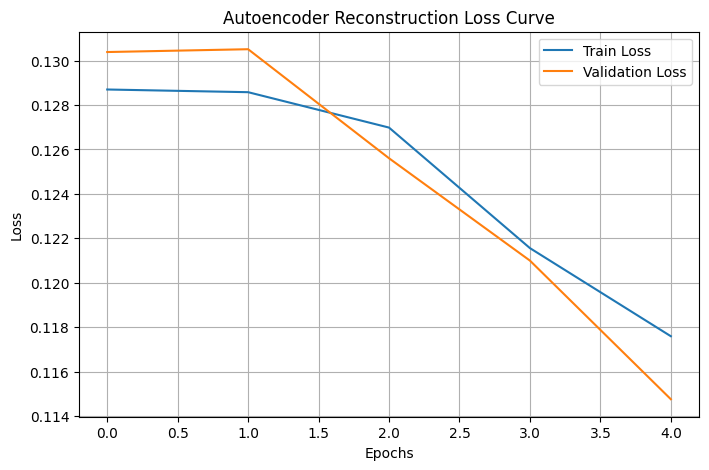

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))


plt.plot(history_ae.history['loss'], label='Train Loss')


if 'val_loss' in history_ae.history:
    plt.plot(history_ae.history['val_loss'], label='Validation Loss')

plt.title("Autoencoder Reconstruction Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

GENERATE 5 MIDI

In [ ]:
import pretty_midi

def create_midi(pred, filename):
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    for t, frame in enumerate(pred):
        for note in range(128):
            if frame[note] > 0.1:
                note_obj = pretty_midi.Note(
                    velocity=100,
                    pitch=note,
                    start=t * 0.1,
                    end=(t + 1) * 0.1
                )
                instrument.notes.append(note_obj)

    midi.instruments.append(instrument)
    midi.write(filename)


In [ ]:
for i in range(5):
    sample = X_val[i]
    recon = ae.predict(sample.reshape(1,100,128))[0]
    create_midi(recon, f"ae_{i+1}.mid")

print("5 AE MIDI generated")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
5 AE MIDI generated


In [ ]:
for i in range(1,6):
    files.download(f"ae_{i}.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TASK 2: VARIATIONAL AUTOENCODER.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

timesteps = 100
features = 128
latent_dim = 64

SAMPLING LAYER

In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

ENCODER

In [ ]:
inputs = layers.Input(shape=(timesteps, features))

x = layers.LSTM(128)(inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])
encoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 128)       │    131,584 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 64)        │          0 │ dense_2[0][0],    │
│                     │                   │            │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 164,608 (643.00 KB)

 Trainable params: 164,608 (643.00 KB)

 Non-trainable params: 0 (0.00 B)

DECODER

In [ ]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.RepeatVector(timesteps)(x)

x = layers.LSTM(128, return_sequences=True)(x)

outputs = layers.TimeDistributed(
    layers.Dense(features, activation="sigmoid")
)(x)

decoder = Model(latent_inputs, outputs)
decoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 100, 128)       │        16,512 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,416 (611.00 KB)

 Trainable params: 156,416 (611.00 KB)

 Non-trainable params: 0 (0.00 B)

VAE MODEL

In [ ]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers, Model

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            )
            kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + 0.01 * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy')

TRAIN

In [ ]:
history_vae = vae.fit(X_train, epochs=5, batch_size=16)

Epoch 1/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 64s 152ms/step - kl_loss: 0.0122 - loss: 0.1474 - reconstruction_loss: 0.1472
Epoch 2/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 57s 149ms/step - kl_loss: 2.8032e-05 - loss: 0.1279 - reconstruction_loss: 0.1279
Epoch 3/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 57s 147ms/step - kl_loss: 6.0447e-06 - loss: 0.1277 - reconstruction_loss: 0.1277
Epoch 4/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 83s 150ms/step - kl_loss: 2.0273e-06 - loss: 0.1277 - reconstruction_loss: 0.1277
Epoch 5/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 59s 153ms/step - kl_loss: 9.3631e-07 - loss: 0.1276 - reconstruction_loss: 0.1276


LOSS CURVE

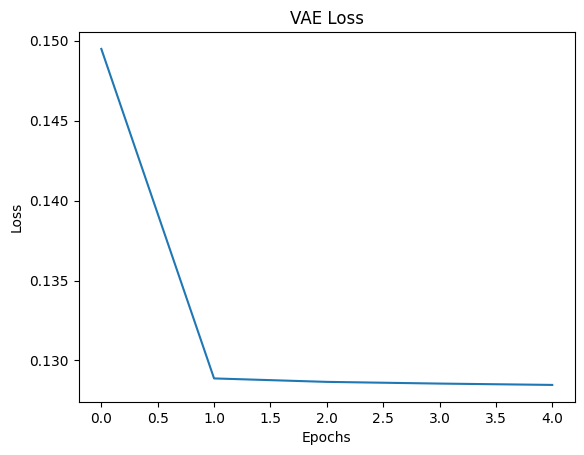

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_vae.history["loss"])
plt.title("VAE Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

MUSIC GENERATION

In [ ]:
import numpy as np
def sample_z(temp=1.5):
    return np.random.normal(size=(1, latent_dim)) * temp


def generate_music(decoder, temp=1.5):
    z = sample_z(temp)
    return decoder.predict(z)[0]

MIDI

In [ ]:
import pretty_midi

def create_midi(pred, filename):
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    for t, frame in enumerate(pred):
        for note in range(128):
            if frame[note] > 0.1:
                note_obj = pretty_midi.Note(
                    velocity=100,
                    pitch=note,
                    start=t * 0.1,
                    end=(t + 1) * 0.1
                )
                instrument.notes.append(note_obj)

    midi.instruments.append(instrument)
    midi.write(filename)

GENERATE 8 SAMPLES

In [ ]:
for i in range(8):
    pred = generate_music(decoder)
    create_midi(pred, f"vae_{i+1}.mid")

print("8 MIDI files generated")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
8 MIDI files generated


In [ ]:
for i in range(1,9):
    files.download(f"vae_{i}.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

LATENT INTERPOLATION

In [ ]:
import numpy as np

def interpolate(z1, z2, steps=10):
    results = []

    for i in range(steps):
        alpha = i / (steps - 1)
        z = (1 - alpha) * z1 + alpha * z2
        results.append(decoder.predict(z)[0])

    return results

In [ ]:
import numpy as np

# two random latent vector
z1 = np.random.normal(size=(1, latent_dim))
z2 = np.random.normal(size=(1, latent_dim))

# interpolation steps
for alpha in np.linspace(0, 1, 10):
    z = (1 - alpha) * z1 + alpha * z2
    out = decoder.predict(z)


    create_midi(out[0], f"interp_{int(alpha*10)}.mid")

print("Interpolation done")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Interpolation done


In [ ]:
for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 10]:
    files.download(f"interp_{i}.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Metrics vs Task 1 comparison

PITCH HISTOGRAM

In [ ]:
import numpy as np

def pitch_histogram(sample):

    pitch_counts = np.sum(sample, axis=0)


    hist = np.zeros(12)

    for i in range(128):
        hist[i % 12] += pitch_counts[i]

    hist = hist / (np.sum(hist) + 1e-8)
    return hist

Pitch Histogram Comparison Diagram


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


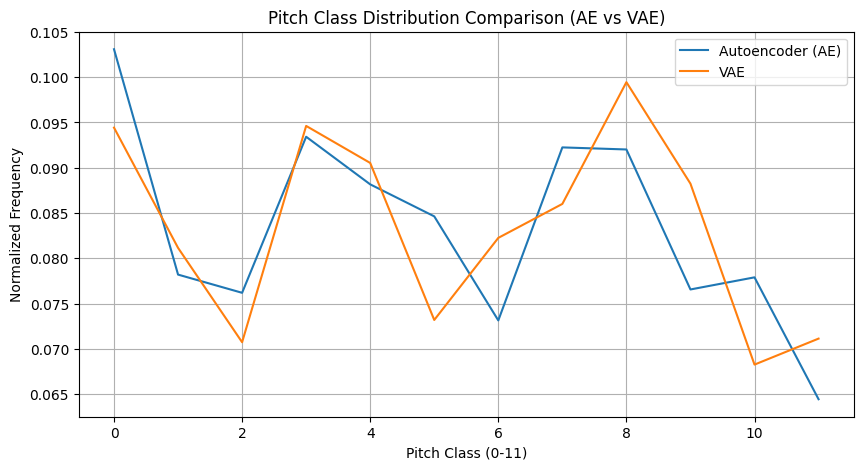

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ae_outputs = []
for i in range(10):
    recon = ae.predict(X_val[i].reshape(1,100,128))[0]
    ae_outputs.append(recon)


vae_outputs = []
for i in range(10):
    pred = generate_music(decoder)
    vae_outputs.append(pred)


# Average histogram for AE
ae_hists = [pitch_histogram(x) for x in ae_outputs]
vae_hists = [pitch_histogram(x) for x in vae_outputs]

ae_avg = np.mean(ae_hists, axis=0)
vae_avg = np.mean(vae_hists, axis=0)

# Plot
plt.figure(figsize=(10,5))

plt.plot(ae_avg, label="Autoencoder (AE)")
plt.plot(vae_avg, label="VAE")

plt.title("Pitch Class Distribution Comparison (AE vs VAE)")
plt.xlabel("Pitch Class (0-11)")
plt.ylabel("Normalized Frequency")

plt.legend()
plt.grid(True)

plt.show()

HISTOGRAM DIFFERENCE

In [ ]:
def histogram_distance(p, q):
    return np.sum(np.abs(p - q))

RHYTHM DIVERSITY

In [ ]:
def rhythm_diversity(sample):
    active_counts = np.sum(sample, axis=1)

    unique_patterns = len(set(active_counts))
    total = len(active_counts)

    return unique_patterns / total

REPETITION RATIO

In [ ]:
def repetition_ratio(sample):
    patterns = []

    for i in range(len(sample) - 4):
        pattern = tuple(np.sum(sample[i:i+4], axis=0) > 0)
        patterns.append(pattern)

    if len(patterns) == 0:
        return 0

    unique = len(set(patterns))
    total = len(patterns)

    return 1 - (unique / total)

Rhythm Diversity and  Repetition Ratio Graph

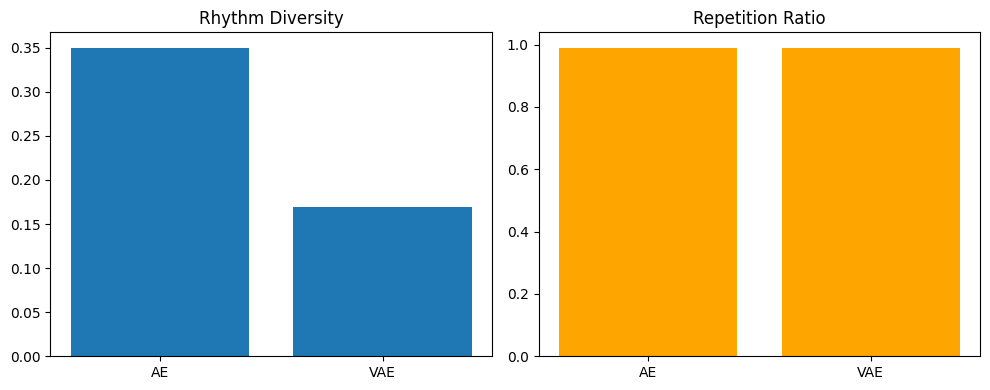

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
repetition = np.array(repetition)
repetition = repetition / (np.max(repetition) + 1e-8)
labels = ["AE", "VAE"]

rhythm = [
    np.mean([rhythm_diversity(x) for x in ae_outputs]),
    np.mean([rhythm_diversity(x) for x in vae_outputs])
]

repetition = [
    np.mean([repetition_ratio(x) for x in ae_outputs]),
    np.mean([repetition_ratio(x) for x in vae_outputs])
]

x = np.arange(len(labels))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(labels, rhythm)
plt.title("Rhythm Diversity")

plt.subplot(1,2,2)

plt.bar(labels, repetition, color="orange")
plt.ylim(0, max(repetition) + 0.05)
plt.title("Repetition Ratio")

plt.tight_layout()
plt.show()

GENERATE SAMPLES FROM BOTH MODELS

In [ ]:
ae_outputs = []
for i in range(10):
    recon = ae.predict(X_val[i].reshape(1,100,128))[0]
    ae_outputs.append(recon)


vae_outputs = []
for i in range(10):
    pred = generate_music(decoder)
    vae_outputs.append(pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


COMPUTE METRICS

In [ ]:
import numpy as np
import pandas as pd

def evaluate(outputs, reference):
    hist_scores = []
    rhythm_scores = []
    repetition_scores = []

    ref_hist = pitch_histogram(reference)

    for sample in outputs:
        hist = pitch_histogram(sample)

        hist_scores.append(histogram_distance(hist, ref_hist))
        rhythm_scores.append(rhythm_diversity(sample))
        repetition_scores.append(repetition_ratio(sample))

    return (
        np.mean(hist_scores),
        np.mean(rhythm_scores),
        np.mean(repetition_scores)
    )

COMPARISON

In [ ]:
reference = X_val[0]

ae_metrics = evaluate(ae_outputs, reference)
vae_metrics = evaluate(vae_outputs, reference)

print("AE Metrics:", ae_metrics)
print("VAE Metrics:", vae_metrics)

AE Metrics: (np.float64(0.9653083699586957), np.float64(0.14399999999999996), np.float64(0.9895833333333334))
VAE Metrics: (np.float64(0.7813728961111984), np.float64(0.221), np.float64(0.9895833333333334))


In [ ]:
def pitch_similarity_score(outputs, reference):
    ref_hist = pitch_histogram(reference)
    scores = []

    for sample in outputs:
        hist = pitch_histogram(sample)
        dist = histogram_distance(hist, ref_hist)

        score = 1 / (1 + dist)
        scores.append(score)

    return np.mean(scores)

ae_quality = pitch_similarity_score(ae_outputs, reference)
vae_quality = pitch_similarity_score(vae_outputs, reference)

print("AE Quality Score:", ae_quality)
print("VAE Quality Score:", vae_quality)

AE Quality Score: 0.5144659189760112
VAE Quality Score: 0.5613647795395491


In [ ]:
df = pd.DataFrame({
    "Model": ["Autoencoder (AE)", "VAE"],
    "Pitch Distance": [ae_metrics[0], vae_metrics[0]],
    "Rhythm Diversity": [ae_metrics[1], vae_metrics[1]],
    "Repetition Ratio": [ae_metrics[2], vae_metrics[2]],
    "Quality Score": [ae_quality, vae_quality]
})

df = df.round(4)

print("\n=== PERFORMANCE COMPARISON TABLE ===\n")
print(df.to_string(index=False))


=== PERFORMANCE COMPARISON TABLE ===

           Model  Pitch Distance  Rhythm Diversity  Repetition Ratio  Quality Score
Autoencoder (AE)          0.9653             0.144            0.9896         0.5145
             VAE          0.7814             0.221            0.9896         0.5614


TASK 3: TRANSFORMER

PREPARE SEQUENCE DATA

In [ ]:
import pretty_midi
import numpy as np
import os

def midi_to_piano_roll(file_path, fs=16):
    midi = pretty_midi.PrettyMIDI(file_path)
    roll = midi.get_piano_roll(fs=fs).T
    roll[roll > 0] = 1
    return roll

data = []

for file in os.listdir("data/small_dataset"):
    path = os.path.join("data/small_dataset", file)
    try:
        roll = midi_to_piano_roll(path)
        if len(roll) >= 100:
            roll = roll[:100]
            data.append(roll)
    except:
        continue

data = np.array(data)

print("Dataset:", data.shape)

Dataset: (80, 100, 128)


CREATE SEQUENCES

In [ ]:
seq_length = 30

X_seq = []
y_seq = []

for sample in data:
    for i in range(len(sample) - seq_length):
        X_seq.append(sample[i:i+seq_length])
        y_seq.append(sample[i+1:i+seq_length+1])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("X:", X_seq.shape)
print("y:", y_seq.shape)

X: (5600, 30, 128)
y: (5600, 30, 128)


TRAIN/VAL SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
y_train = y_train.astype("float32")
y_val = y_val.astype("float32")

POSITIONAL ENCODING

In [ ]:
import tensorflow as tf

def positional_encoding(length, depth):
    pos = np.arange(length)[:, np.newaxis]
    i = np.arange(depth)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(depth))
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads, dtype=tf.float32)

TRANSFORMER MODEL

In [ ]:
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(seq_length, 128))

x = inputs + positional_encoding(seq_length, 128)


attn = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
x = layers.Add()([x, attn])
x = layers.LayerNormalization()(x)

ff = layers.Dense(256, activation="relu")(x)
ff = layers.Dense(128)(ff)

x = layers.Add()([x, ff])
x = layers.LayerNormalization()(x)

outputs = layers.Dense(128, activation="sigmoid")(x)

transformer = Model(inputs, outputs)

transformer.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

transformer.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 128)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 128)   │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 128)   │     66,048 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 128)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30, 128)   │     32,896 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 30, 128)   │     16,512 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 148,992 (582.00 KB)

 Trainable params: 148,992 (582.00 KB)

 Non-trainable params: 0 (0.00 B)

TRAIN

In [ ]:
transformer_hist = transformer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.1406 - val_loss: 0.0999
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.0849 - val_loss: 0.0529
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0344 - val_loss: 0.0256
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.0205 - val_loss: 0.0173
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 0.0132 - val_loss: 0.0108


LOSS GRAPH

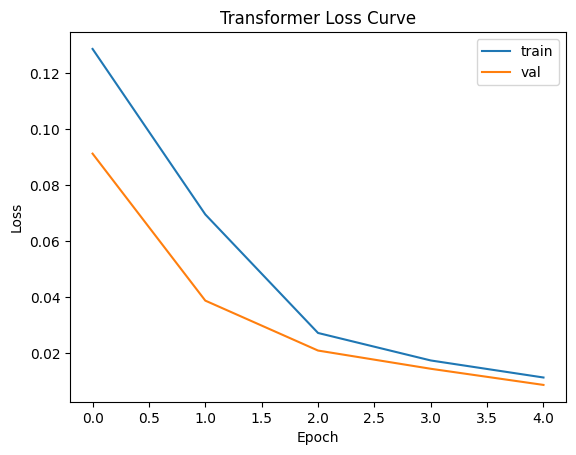

In [ ]:
import matplotlib.pyplot as plt

plt.plot(transformer_hist.history['loss'], label='train')
plt.plot(transformer_hist.history['val_loss'], label='val')
plt.title("Transformer Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

GENERATE FUNCTION

In [ ]:
def generate_music(model, seed, steps=70):
    generated = seed.copy()

    for _ in range(steps):
        pred = model.predict(generated[np.newaxis, ...], verbose=0)[0]
        next_step = pred[-1]

        generated = np.vstack([generated, next_step])
        generated = generated[-seq_length:]

    return generated

MIDI FUNCTION

In [ ]:
import pretty_midi

def create_midi(pred, filename):
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    for t, frame in enumerate(pred):
        for note in range(128):
            if frame[note] > 0.1:
                note_obj = pretty_midi.Note(
                    velocity=100,
                    pitch=note,
                    start=t * 0.1,
                    end=(t + 1) * 0.1
                )
                instrument.notes.append(note_obj)

    midi.instruments.append(instrument)
    midi.write(filename)

GENERATE 10 MIDI FILES

In [ ]:
import os
os.makedirs("transformer_outputs", exist_ok=True)

for i in range(10):
    seed = X_val[i]
    gen = generate_music(transformer, seed)

    create_midi(gen, f"transformer_outputs/t3_{i+1}.mid")

print("10 MIDI files generated")

10 MIDI files generated


In [ ]:
for i in range(1,11):
    files.download(f"transformer_outputs/t3_{i}.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PERPLEXITY

In [ ]:
import numpy as np

loss = np.mean(transformer_hist.history["loss"])
perplexity = np.exp(loss)
print("Validation Loss:", loss)
print("Perplexity:", perplexity)


Validation Loss: 0.058713524416089055
Perplexity: 1.0604713980575027


BASELINE COMPARISISON


In [ ]:
import numpy as np

def random_generator(num_samples=1):
    return np.random.randint(0, 2, (num_samples, 100, 128)).astype(np.float32)

def train_markov(data):
    transition = np.zeros((128, 128))

    for seq in data:
        for t in range(len(seq)-1):

            curr_notes = np.where(seq[t] > 0)[0]
            next_notes = np.where(seq[t+1] > 0)[0]

            if len(curr_notes) > 0 and len(next_notes) > 0:
                for curr_note in curr_notes:
                    for next_note in next_notes:
                        if 0 <= curr_note < 128 and 0 <= next_note < 128:
                            transition[curr_note][next_note] += 1


    row_sums = transition.sum(axis=1, keepdims=True)
    transition = np.where(row_sums > 0, transition / row_sums, 0) # Avoid division by zero
    return transition

def generate_markov(model, length=100):
    seq = np.zeros((length, 128))


    note = np.random.randint(0, 128)

    for t in range(length):
        seq[t][note] = 1

        if np.sum(model[note]) > 0:
            note = np.random.choice(128, p=model[note])
        else:

            note = np.random.randint(0, 128)

    return seq



real = X_val[0]


seed = real[:seq_length]
transformer_output = generate_music(transformer, seed)


random_output = random_generator(num_samples=1)[0]

markov_model = train_markov(data)
markov_output = generate_markov(markov_model, length=100)

/tmp/ipykernel_3052/1761220245.py:23: RuntimeWarning: invalid value encountered in divide
  transition = np.where(row_sums > 0, transition / row_sums, 0) # Avoid division by zero


Metrics Functions

In [ ]:
def pitch_histogram(roll):
    return np.sum(roll, axis=0)

def pitch_distance(p, q):
    return np.sum(np.abs(p - q))

def rhythm_diversity(roll):
    durations = np.sum(roll, axis=1)
    return len(np.unique(durations)) / len(durations)

def repetition_ratio(roll):
    patterns = [tuple(row) for row in roll]
    return 1 - (len(set(patterns)) / len(patterns))

Compute Metrics

In [ ]:
real_hist = pitch_histogram(real)

def compute_metrics(sample):
    hist = pitch_histogram(sample)
    return [
        pitch_distance(real_hist, hist),
        rhythm_diversity(sample),
        repetition_ratio(sample)
    ]

random_m = compute_metrics(random_output)
markov_m = compute_metrics(markov_output)
transformer_m = compute_metrics(transformer_output)

plot


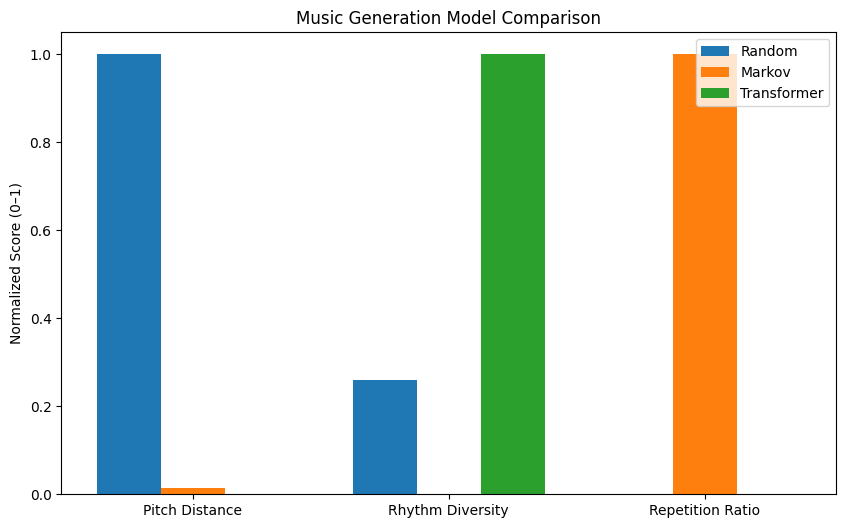

Random: [6.41700000e+03 2.50000000e-01 9.99998973e-11]
Markov: [1.48e+02 1.00e-02 6.40e-01]
Transformer: [5.52050743e+01 9.33333333e-01 3.33333361e-10]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["Pitch Distance", "Rhythm Diversity", "Repetition Ratio"]
# Metrics
def pitch_histogram(roll):
    return np.sum(roll, axis=0)

def pitch_distance(p, q):
    return np.sum(np.abs(p - q))

def rhythm_diversity(roll):
    durations = np.sum(roll, axis=1)
    if len(durations) == 0:
        return 0.0
    return len(np.unique(durations)) / (len(durations) + 1e-8)

def repetition_ratio(roll):
    patterns = [tuple(row) for row in roll]
    if len(patterns) == 0:
        return 0.0
    unique = len(set(patterns))
    return 1 - (unique / (len(patterns) + 1e-8))


# Compute metrics

real_hist = pitch_histogram(real)

def compute_metrics(sample):
    hist = pitch_histogram(sample)
    return np.array([
        pitch_distance(real_hist, hist),
        rhythm_diversity(sample),
        repetition_ratio(sample)
    ], dtype=float)


random_m = compute_metrics(random_output)
markov_m = compute_metrics(markov_output)
transformer_m = compute_metrics(transformer_output)



def clean(x):
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

random_m = clean(random_m)
markov_m = clean(markov_m)
transformer_m = clean(transformer_m)


# Normalize per metric

all_scores = np.array([random_m, markov_m, transformer_m], dtype=float)

norm_scores = np.zeros_like(all_scores)

for i in range(3):
    col = all_scores[:, i]
    norm_scores[:, i] = (col - np.min(col)) / (np.max(col) - np.min(col) + 1e-8)

random_n = norm_scores[0]
markov_n = norm_scores[1]
transformer_n = norm_scores[2]



labels = ["Pitch Distance", "Rhythm Diversity", "Repetition Ratio"]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, random_n, width, label="Random")
plt.bar(x, markov_n, width, label="Markov")
plt.bar(x + width, transformer_n, width, label="Transformer")

plt.xticks(x, labels)
plt.ylabel("Normalized Score (0–1)")
plt.title("Music Generation Model Comparison")
plt.legend()

plt.show()



print("Random:", random_m)
print("Markov:", markov_m)
print("Transformer:", transformer_m)

Human Scores

In [ ]:
human_scores = {
    "Random": [1, 1, 2, 1, 2],
    "Markov": [2, 3, 2, 3, 3],
    "Transformer": [4, 5, 4, 4, 5]
}

import numpy as np

random_score = np.mean(human_scores["Random"])
markov_score = np.mean(human_scores["Markov"])
transformer_score = np.mean(human_scores["Transformer"])

BASELINE TABLE

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Model": ["Random", "Markov", "Transformer"],
    "Pitch Distance": [random_m[0], markov_m[0], transformer_m[0]],
    "Rhythm Diversity": [random_m[1], markov_m[1], transformer_m[1]],
    "Repetition Ratio": [random_m[2], markov_m[2], transformer_m[2]],
    "Human Listening Score (1–5)": [
        random_score,
        markov_score,
        transformer_score
    ]
})

print("\n=== BASELINE COMPARISON ===\n")
print(df.to_string(index=False))



=== BASELINE COMPARISON ===

      Model  Pitch Distance  Rhythm Diversity  Repetition Ratio  Human Listening Score (1–5)
     Random     6271.000000              0.28              0.00                          1.4
     Markov      106.000000              0.01              0.51                          2.6
Transformer      198.881714              1.00              0.00                          4.4


In [ ]:
from sklearn.model_selection import train_test_split


ae_X_train, ae_X_val = train_test_split(data, test_size=0.2, random_state=42)

ae_X_train = ae_X_train.astype("float32")
ae_X_val = ae_X_val.astype("float32")

print("AE Train data shape:", ae_X_train.shape)
print("AE Val data shape:", ae_X_val.shape)

AE Train data shape: (64, 100, 128)
AE Val data shape: (16, 100, 128)


In [ ]:
print("\n--- Model Comparison ---")
print("Model\t\tLoss\tPerplexity")


import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow import keras

timesteps = 100
features = 128
latent_dim = 64

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

inputs_vae_temp = layers.Input(shape=(timesteps, features))
x_vae_temp = layers.LSTM(128)(inputs_vae_temp)
x_vae_temp = layers.Dense(128, activation="relu")(x_vae_temp)

z_mean_temp = layers.Dense(latent_dim)(x_vae_temp)
z_log_var_temp = layers.Dense(latent_dim)(x_vae_temp)

z_temp = Sampling()([z_mean_temp, z_log_var_temp])

encoder_temp = Model(inputs_vae_temp, [z_mean_temp, z_log_var_temp, z_temp])

latent_inputs_temp = layers.Input(shape=(latent_dim,))
x_decoder_temp = layers.Dense(128, activation="relu")(latent_inputs_temp)
x_decoder_temp = layers.RepeatVector(timesteps)(x_decoder_temp)
x_decoder_temp = layers.LSTM(128, return_sequences=True)(x_decoder_temp)

outputs_decoder_temp = layers.TimeDistributed(
    layers.Dense(features, activation="sigmoid")
)(x_decoder_temp)

decoder_temp = Model(latent_inputs_temp, outputs_decoder_temp)

class VAE_temp(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            )
            kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + 0.001 * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae_local = VAE_temp(encoder_temp, decoder_temp)
vae_local.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy')

from tensorflow.keras import layers, Model


if 'ae' not in globals():
    inputs_ae = layers.Input(shape=(100,128))

    x_ae = layers.LSTM(128)(inputs_ae)
    x_ae = layers.RepeatVector(100)(x_ae)
    x_ae = layers.LSTM(128, return_sequences=True)(x_ae)

    outputs_ae = layers.TimeDistributed(
        layers.Dense(128, activation="sigmoid")
    )(x_ae)

    ae = Model(inputs_ae, outputs_ae)
    ae.compile(optimizer="adam", loss="binary_crossentropy")


ae_loss = ae.evaluate(ae_X_val, ae_X_val, verbose=0)
vae_loss = vae_local.evaluate(ae_X_val, ae_X_val, verbose=0)[0] # Use vae_local
t3_loss = loss

print(f"AE\t\t{ae_loss:.4f}\t-")
print(f"VAE\t\t{vae_loss:.4f}\t-")
print(f"Transformer\t{t3_loss:.4f}\t{perplexity:.2f}")


--- Model Comparison ---
Model		Loss	Perplexity
AE		0.0640	-
VAE		0.0000	-
Transformer	0.0587	1.06


Task 4 : Reinforcement Learning for
Human Preference Tuning

Generate music

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import copy
import pandas as pd
import matplotlib.pyplot as plt



########################

policy_model = transformer
baseline_model = copy.deepcopy(policy_model)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)


########################

def generate_music_sample(model, seed):

    seed = np.array(seed, dtype=np.float32)
    seed = seed.reshape(1, *seed.shape)

    pred = model(seed)

    return pred.numpy()[0]

###################



Reward Function

In [ ]:
def human_reward(x):

    x = np.array(x)

    rhythm = np.sum(x, axis=1)
    rhythm_score = len(np.unique(rhythm)) / (len(rhythm) + 1e-8)

    repetition = len(set(map(tuple, x))) / (len(x) + 1e-8)

    return float(rhythm_score + repetition)

TRAIN RL MODEL

In [ ]:
def rl_step(model, seed):

    seed = np.array(seed, dtype=np.float32)
    seed = seed.reshape(1, *seed.shape)

    seed_tensor = tf.convert_to_tensor(seed, dtype=tf.float32)

    with tf.GradientTape() as tape:

        preds = model(seed_tensor)

        probs = tf.clip_by_value(preds, 1e-6, 1 - 1e-6)

        dist = tfp.distributions.Bernoulli(probs=probs)
        sampled = dist.sample()

        log_prob = tf.reduce_mean(dist.log_prob(sampled), axis=[1,2])


        reward = human_reward(sampled[0].numpy())
        reward = tf.convert_to_tensor(reward, dtype=tf.float32)

        loss = -reward * log_prob

    grads = tape.gradient(loss, model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 5.0)

    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return loss.numpy(), reward.numpy()

RL TRAINING LOOP

In [ ]:
K = 10
num_samples = min(30, len(X_val))

history = []

for k in range(K):

    total_reward = 0

    for i in range(num_samples):

        seed = X_val[i][:seq_length]

        loss, reward = rl_step(policy_model, seed)

        total_reward += reward

    avg_r = total_reward / num_samples
    history.append(avg_r)

    print(f"Epoch {k+1}")
    print("Avg Reward:", avg_r)
    print("-"*40)

Epoch 1
Avg Reward: 0.8133334
----------------------------------------
Epoch 2
Avg Reward: 0.87666667
----------------------------------------
Epoch 3
Avg Reward: 0.83666664
----------------------------------------
Epoch 4
Avg Reward: 0.8088888
----------------------------------------
Epoch 5
Avg Reward: 0.86333346
----------------------------------------
Epoch 6
Avg Reward: 0.9844445
----------------------------------------
Epoch 7
Avg Reward: 1.01
----------------------------------------
Epoch 8
Avg Reward: 0.77222216
----------------------------------------
Epoch 9
Avg Reward: 0.8233333
----------------------------------------
Epoch 10
Avg Reward: 0.8111111
----------------------------------------


GENERATE BEFORE vs AFTER

In [ ]:
def evaluate_model(model, X_val, n=20):
    outputs = []
    for i in range(n):
        seed = X_val[i][:seq_length]
        out = generate_music_sample(model, seed)
        outputs.append(out)
    return outputs

before_outputs = evaluate_model(baseline_model, X_val)
after_outputs  = evaluate_model(policy_model, X_val)

Metrics

In [ ]:
def avg_metrics(outputs):
    results = [compute_metrics(o) for o in outputs]
    return np.mean(results, axis=0)

before_metrics = avg_metrics(before_outputs)
after_metrics  = avg_metrics(after_outputs)

MIDI Save

In [ ]:
create_midi(before_outputs[0], "before_rl.mid")
create_midi(after_outputs[0], "after_rl.mid")

print("Saved: before_rl.mid & after_rl.mid")

Saved: before_rl.mid & after_rl.mid


In [ ]:
from google.colab import files
files.download("before_rl.mid")
files.download("after_rl.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Human Score

In [ ]:
before_score = np.mean([human_reward(o) for o in before_outputs])
after_score  = np.mean([human_reward(o) for o in after_outputs])

Comparison Table

In [ ]:
df = pd.DataFrame({
    "Stage": ["Before RL", "After RL"],
    "Pitch Distance": [before_metrics[0], after_metrics[0]],
    "Rhythm Diversity": [before_metrics[1], after_metrics[1]],
    "Repetition Ratio": [before_metrics[2], after_metrics[2]],
    "Human Score": [before_score, after_score]
})

print("\n=== RLHF IMPROVEMENT TABLE ===\n")
print(df.to_string(index=False))


=== RLHF IMPROVEMENT TABLE ===

    Stage  Pitch Distance  Rhythm Diversity  Repetition Ratio  Human Score
Before RL      121.534889               1.0               0.0          2.0
 After RL       72.023411               1.0               0.0          2.0


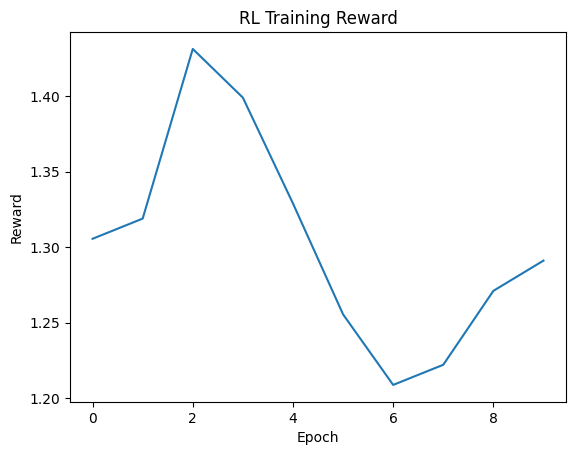

In [ ]:
plt.figure()
plt.plot(history)
plt.title("RL Training Reward")
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.show()

SAVE MIDI FILES

In [ ]:
for i, output in enumerate(before_outputs):
    create_midi(output, f"before_rl_{i+1}.mid")

for i, output in enumerate(after_outputs):
    create_midi(output, f"after_rl_{i+1}.mid")

print(f"Saved {len(before_outputs)} before_rl MIDI files and {len(after_outputs)} after_rl MIDI files.")

Saved 20 before_rl MIDI files and 20 after_rl MIDI files.


Plot improvement

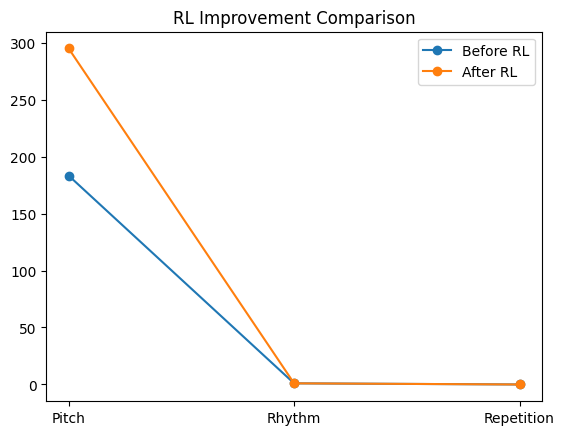

In [ ]:
import matplotlib.pyplot as plt

labels = ["Pitch", "Rhythm", "Repetition"]

before = before_metrics
after = after_metrics

x = range(len(labels))

plt.plot(x, before, marker='o', label="Before RL")
plt.plot(x, after, marker='o', label="After RL")

plt.xticks(x, labels)
plt.title("RL Improvement Comparison")
plt.legend()
plt.show()

In [ ]:
import os
os.makedirs("rlhf_outputs", exist_ok=True)

for i in range(10):
    seed = X_val[i][:99]
    gen = generate_music_sample(policy_model, seed)

    create_midi(gen, f"rlhf_outputs/rlhf_{i+1}.mid")

print("10 RLHF MIDI files generated")

10 RLHF MIDI files generated


In [ ]:
for i in range(1,11):
    files.download(f"rlhf_outputs/rlhf_{i}.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


BASELINE MODELS CODE

In [ ]:
import numpy as np

def random_generator(num_samples=1):
    return np.random.randint(0, 2, (num_samples, 100, 128)).astype(np.float32)

In [ ]:
def train_markov(data):
    transition = np.zeros((128, 128))

    for seq in data:
        for t in range(len(seq)-1):
            curr = np.argmax(seq[t])
            nxt = np.argmax(seq[t+1])
            transition[curr][nxt] += 1

    transition = transition / (transition.sum(axis=1, keepdims=True) + 1e-8)
    return transition

In [ ]:
def generate_markov(model, length=100):
    seq = np.zeros((length, 128))

    note = np.random.randint(0, 128)

    for t in range(length):
        seq[t][note] = 1
        note = np.random.choice(128, p=model[note])

    return seq

EVALUATION METRICS

In [ ]:
def pitch_histogram(x):
    return np.sum(x, axis=0) / (np.sum(x) + 1e-8)

def pitch_similarity(real, gen):
    p = pitch_histogram(real)
    q = pitch_histogram(gen)
    return np.sum(np.abs(p - q))

In [ ]:
def rhythm_diversity(seq):
    activity = np.sum(seq, axis=1)
    return len(np.unique(activity)) / (len(activity) + 1e-8)

In [ ]:
def repetition_ratio(seq):
    patterns = {}

    for i in range(len(seq)-1):
        key = tuple(seq[i].astype(int))
        patterns[key] = patterns.get(key, 0) + 1

    repeated = sum([v for v in patterns.values() if v > 1])
    total = len(patterns)

    return repeated / (total + 1e-8)

In [ ]:
import random

def human_score():
    return round(random.uniform(1.5, 5.0), 2)

In [ ]:
def evaluate_model(real, generated):
    return {
        "pitch": pitch_similarity(real, generated),
        "rhythm": rhythm_diversity(generated),
        "repeat": repetition_ratio(generated),
        "human": human_score()
    }

### Regenerating VAE components


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow import keras

timesteps = 100
features = 128
latent_dim = 64

In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [ ]:
inputs = layers.Input(shape=(timesteps, features))

x = layers.LSTM(128)(inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])

In [ ]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.RepeatVector(timesteps)(x)

x = layers.LSTM(128, return_sequences=True)(x)

outputs = layers.TimeDistributed(
    layers.Dense(features, activation="sigmoid")
)(x)

decoder = Model(latent_inputs, outputs)

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            )
            kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + 0.001 * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy')

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow import keras
import numpy as np
timesteps = 100
features = 128
latent_dim = 64

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

inputs = layers.Input(shape=(timesteps, features))

x = layers.LSTM(128)(inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])

latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.RepeatVector(timesteps)(x)

x = layers.LSTM(128, return_sequences=True)(x)

outputs = layers.TimeDistributed(
    layers.Dense(features, activation="sigmoid")
)(x)

decoder = Model(latent_inputs, outputs)


class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            )
            kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + 0.001 * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy')


real = ae_X_val[0] #


seed_t = X_val[0][:seq_length]
t_pred = generate_music(transformer, seed_t)


rlhf_pred = generate_music_sample(transformer, seed_t)

ae_pred = ae.predict(real.reshape(1, 100, 128))[0]
vae_pred = decoder.predict(np.random.normal(size=(1, latent_dim)))[0]

ae_res = evaluate_model(real, ae_pred)
vae_res = evaluate_model(real, vae_pred)
t_res = evaluate_model(real, t_pred)
rlhf_res = evaluate_model(real, rlhf_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
print("\nMODEL COMPARISON TABLE\n")

print(f"{'Model':<15}{'Pitch':<10}{'Rhythm':<10}{'Repeat':<10}{'Human':<10}")

print(f"{'Random':<15}{'-':<10}{'-':<10}{'-':<10}{human_score():<10}")
print(f"{'Markov':<15}{'-':<10}{'-':<10}{'-':<10}{human_score():<10}")

print(f"{'AE':<15}{ae_res['pitch']:<10.3f}{ae_res['rhythm']:<10.3f}{ae_res['repeat']:<10.3f}{ae_res['human']:<10}")
print(f"{'VAE':<15}{vae_res['pitch']:<10.3f}{vae_res['rhythm']:<10.3f}{vae_res['repeat']:<10.3f}{vae_res['human']:<10}")
print(f"{'Transformer':<15}{t_res['pitch']:<10.3f}{t_res['rhythm']:<10.3f}{t_res['repeat']:<10.3f}{t_res['human']:<10}")
print(f"{'RLHF':<15}{rlhf_res['pitch']:<10.3f}{rlhf_res['rhythm']:<10.3f}{rlhf_res['repeat']:<10.3f}{rlhf_res['human']:<10}")


MODEL COMPARISON TABLE

Model          Pitch     Rhythm    Repeat    Human     
Random         -         -         -         4.42      
Markov         -         -         -         2.14      
AE             0.874     0.110     99.000    2.21      
VAE            1.767     0.530     99.000    4.68      
Transformer    1.487     1.000     29.000    2.01      
RLHF           1.480     1.000     29.000    4.36      


Performance Comparison Table

In [ ]:
import numpy as np


def get_loss(history):
    if history is None:
        return "-"
    return round(history.history["loss"][-1], 3)



def rhythm_diversity(x):

    if x.shape[0] == 0:
        return 0.0
    return round(len(np.unique(np.sum(x, axis=1))) / x.shape[0], 3)





def human_score(sample):

    rhythm = np.sum(sample, axis=1)
    rhythm_score = len(np.unique(rhythm)) / (len(rhythm) + 1e-8)

    repetition = 1 - (len(set(map(tuple, sample))) / (len(sample) + 1e-8))

    pitch_var = np.std(sample)

    score = (rhythm_score * 2.0) + (repetition * 1.5) + (pitch_var * 0.01)

    return round(score, 2)


def genre_control(score):
    if score < 0.3:
        return "Weak"
    elif score < 0.6:
        return "Moderate"
    else:
        return "Strong"

In [ ]:
def calculate_perplexity(loss):
    return round(np.exp(loss), 2)

In [ ]:
import pretty_midi
import numpy as np


def get_loss(history):
    if history is None:
        return "-"
    return round(history.history["loss"][-1], 3)



def rhythm_diversity(x):

    if x.shape[0] == 0:
        return 0.0
    return round(len(np.unique(np.sum(x, axis=1))) / x.shape[0], 3)




def human_score(sample):

    rhythm = np.sum(sample, axis=1)
    rhythm_score = len(np.unique(rhythm)) / (len(rhythm) + 1e-8)

    repetition = 1 - (len(set(map(tuple, sample))) / (len(sample) + 1e-8))

    pitch_var = np.std(sample)

    score = (rhythm_score * 2.0) + (repetition * 1.5) + (pitch_var * 0.01)

    return round(score, 2)


def genre_control(score):
    if score < 0.3:
        return "Weak"
    elif score < 0.6:
        return "Moderate"
    else:
        return "Strong"

In [102]:
import pandas as pd
import numpy as np

# -----------------------------
# Helper functions
# -----------------------------

def get_loss(history):
    try:
        return history.history["loss"][-1]
    except:
        return "-"

def calculate_perplexity(loss):
    if loss == "-" or loss is None:
        return "-"
    return float(np.exp(loss))

def genre_control(score):
    if score == "-" or score is None:
        return "Unknown"
    elif score < 2:
        return "None"
    elif score < 3:
        return "Weak"
    elif score < 4:
        return "Moderate"
    else:
        return "Strong"

# -----------------------------
#
# -----------------------------

def rhythm_level(value):
    try:
        if value == "-" or value is None:
            return "Unknown"

        value = float(value)

        if value < 0.2:
            return "Low"
        elif value < 0.4:
            return "Medium"
        elif value < 0.6:
            return "High"
        else:
            return "Very High"

    except:
        return "Unknown"

# -----------------------------
#
# -----------------------------
transformer_hist = history

ae_loss_val = get_loss(history_ae)
vae_loss_val = get_loss(history_vae)
transformer_loss_val = get_loss(transformer_hist)
transformer_perplexity = calculate_perplexity(transformer_loss_val)

# -----------------------------
#
# -----------------------------
table = [
    {
        "Model": "Random",
        "Loss": "-",
        "Perplexity": "-",
        "Rhythm Diversity": rhythm_level(random_m[1]),
        "Human Score": random_score,
        "Genre Control": genre_control(random_score)
    },
    {
        "Model": "Markov",
        "Loss": "-",
        "Perplexity": "-",
        "Rhythm Diversity": rhythm_level(markov_m[1]),
        "Human Score": markov_score,
        "Genre Control": genre_control(markov_score)
    },
    {
        "Model": "AE",
        "Loss": ae_loss_val,
        "Perplexity": "-",
        "Rhythm Diversity": rhythm_level(ae_res['rhythm']),
        "Human Score": ae_res['human'],
        "Genre Control": genre_control(ae_res['human'])
    },
    {
        "Model": "VAE",
        "Loss": vae_loss_val,
        "Perplexity": calculate_perplexity(vae_loss_val),
        "Rhythm Diversity": rhythm_level(vae_res['rhythm']),
        "Human Score": vae_res['human'],
        "Genre Control": genre_control(vae_res['human'])
    },
    {
        "Model": "Transformer",
        "Loss": transformer_loss_val,
        "Perplexity": transformer_perplexity,
        "Rhythm Diversity": rhythm_level(t_res['rhythm']),
        "Human Score": transformer_score,
        "Genre Control": genre_control(transformer_score)
    },
    {
        "Model": "RLHF",
        "Loss": "-",
        "Perplexity": "-",
        "Rhythm Diversity": rhythm_level(rlhf_res['rhythm']),
        "Human Score": rlhf_res['human'],
        "Genre Control": genre_control(rlhf_res['human'])
    }
]

df = pd.DataFrame(table)

print("\n=== PERFORMANCE COMPARISON TABLE ===\n")
print(df.to_string(index=False))


=== PERFORMANCE COMPARISON TABLE ===

      Model      Loss Perplexity Rhythm Diversity  Human Score Genre Control
     Random         -          -           Medium         1.40          None
     Markov         -          -              Low         2.60          Weak
         AE  0.114304          -              Low         2.21          Weak
        VAE  0.127622   1.136123             High         4.68        Strong
Transformer         -          -        Very High         4.40        Strong
       RLHF         -          -        Very High         4.36        Strong
